<a href="https://colab.research.google.com/github/kevinfaithbilla/Dataset/blob/main/Stock%20Market%20Analysis%20Using%20Python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MINI PROJECT-1 : STOCK PREDICTION USING PYTHON

**BUSINESS SCENARIO: Data Science extracts meaningful insight from chunks of raw data, which is useful to different business segments for planning their future course of action. Finance is probably one of the first to catch on to this trend with a rise in the penetration of analytics into many aspects of our lives. Here, we will analyze data from the stock market for some technology stocks such as Apple, Google, Amazon, and Microsoft.<br>**


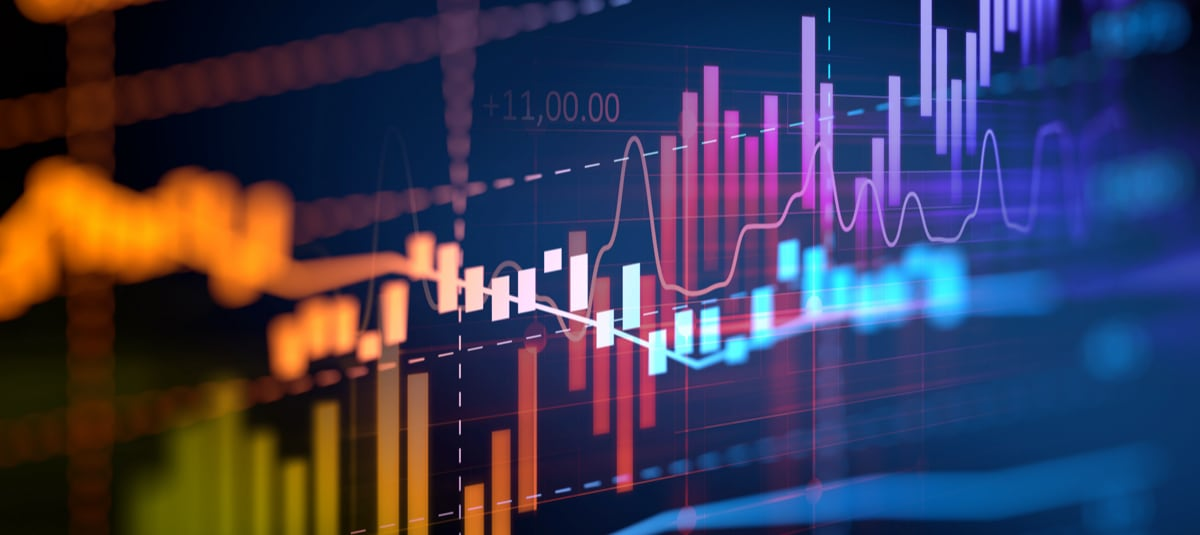

**OBJECTIVE: Use Python libraries such as Pandas, Seaborn, and Matplotlib to extract and analyze the information, visualize it, and look at different ways to analyze the risk of a stock, based on its performance history**.<br>


About the Data: The stocks we have chosen are from various industries and market caps namely,<br>
•Apple<br>
•Google<br>
•Microsoft<br>
•Amazon<br>
For the start, we shall investigate the Amazon stock individually and then move on to the combined analysis.<br>
To know more about stocks and their data please visit the below link:<br>
https://in.finance.yahoo.com/

In [1]:
#importing the libraries
!pip install pandas==2.2.2
!pip install pandas-datareader
!pip install yfinance --upgrade

import numpy as np
import pandas as pd
import yfinance as yf
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.2/144.2 kB 4.2 MB/s eta 0:00:00
  Attempting uninstall: yfinance
    Found existing installation: yfinance 0.2.66
    Uninstalling yfinance-0.2.66:
      Successfully uninstalled yfinance-0.2.66


In [2]:
#setting the data and time
end = datetime.now()
start = datetime(end.year-1,end.month,end.day)

In [3]:
tick1 = 'AMZN'
tick2 = 'AAPL'
tick3 = 'GOOG'
tick4 = 'MSFT'

AMZN = yf.download(tick1, start='2017-08-25', end='2022-08-25', auto_adjust=False)
AAPL = yf.download(tick2, start='2017-08-25', end='2022-08-25', auto_adjust=False)
GOOG = yf.download(tick3, start='2017-08-25', end='2022-08-25', auto_adjust=False)
MSFT = yf.download(tick4, start='2017-08-25', end='2022-08-25', auto_adjust=False)

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [4]:
#Printing the head of Amazon Data
AMZN.head()

Price,Adj Close,Close,High,Low,Open,Volume
Ticker,AMZN,AMZN,AMZN,AMZN,AMZN,AMZN
Date,,,,,,
2017-08-25,47.263000,47.263000,47.881001,47.205002,47.799999,66496000
2017-08-28,47.300999,47.300999,47.650002,47.112499,47.327000,51934000
2017-08-29,47.702999,47.702999,47.799999,46.816502,47.000000,57486000
2017-08-30,48.379501,48.379501,48.470501,47.845501,47.922001,58092000
2017-08-31,49.029999,49.029999,49.049999,48.638000,48.735001,66630000


In [5]:
for df in (AMZN, AAPL, GOOG, MSFT):
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)

In [6]:
print(AMZN.head())

Price       Adj Close      Close       High        Low       Open    Volume
Date                                                                       
2017-08-25  47.263000  47.263000  47.881001  47.205002  47.799999  66496000
2017-08-28  47.300999  47.300999  47.650002  47.112499  47.327000  51934000
2017-08-29  47.702999  47.702999  47.799999  46.816502  47.000000  57486000
2017-08-30  48.379501  48.379501  48.470501  47.845501  47.922001  58092000
2017-08-31  49.029999  49.029999  49.049999  48.638000  48.735001  66630000


In [7]:
AAPL['Company'] = 'Apple'
GOOG['Company'] = 'Google'
MSFT['Company'] = 'Microsoft'
AMZN['Company'] = 'Amazon'

In [8]:
 #Concatinating the all the data
stocks = pd.concat([AAPL,GOOG,MSFT,AMZN],axis=0)

In [9]:
#Reading the data
stocks.head()

Price,Adj Close,Close,High,Low,Open,Volume,Company
Date,,,,,,,
2017-08-25,37.234627,39.965000,40.139999,39.817501,39.912498,101920400,Apple
2017-08-28,37.609638,40.367500,40.500000,39.982498,40.035000,103864000,Apple
2017-08-29,37.945045,40.727501,40.779999,40.000000,40.025002,118067600,Apple
2017-08-30,38.047520,40.837502,40.972500,40.652500,40.950001,109078400,Apple
2017-08-31,38.198921,41.000000,41.130001,40.869999,40.910000,107140400,Apple


In [10]:
#Perform cleaning.
print(stocks.isna().sum())
print(stocks.duplicated().sum())

Price
Adj Close    0
Close        0
High         0
Low          0
Open         0
Volume       0
Company      0
dtype: int64
0


In [11]:
stocks.isna().sum()

,0
Price,
Adj Close,0
Close,0
High,0
Low,0
Open,0
Volume,0
Company,0


In [12]:
stocks.to_csv('Stocks.csv',index=False)

In [13]:
companies = stocks['Company'].drop_duplicates().values
print(companies)

['Apple' 'Google' 'Microsoft' 'Amazon']


In [14]:
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

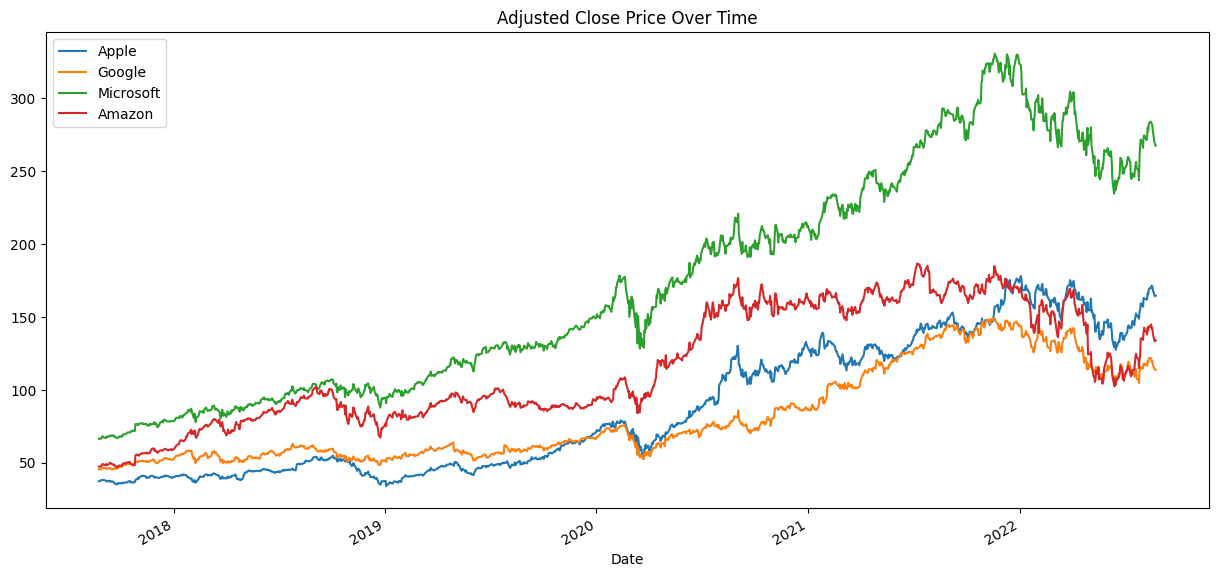

In [15]:
#•What was the change in stock price over time?
grouped = stocks.groupby('Company')
fig, ax = plt.subplots(figsize=(15, 7))
for comp in companies:
    stock = grouped.get_group(comp)
    stock['Adj Close'].plot(legend=True, ax=ax)
ax.legend(companies)
plt.title("Adjusted Close Price Over Time")
plt.show()



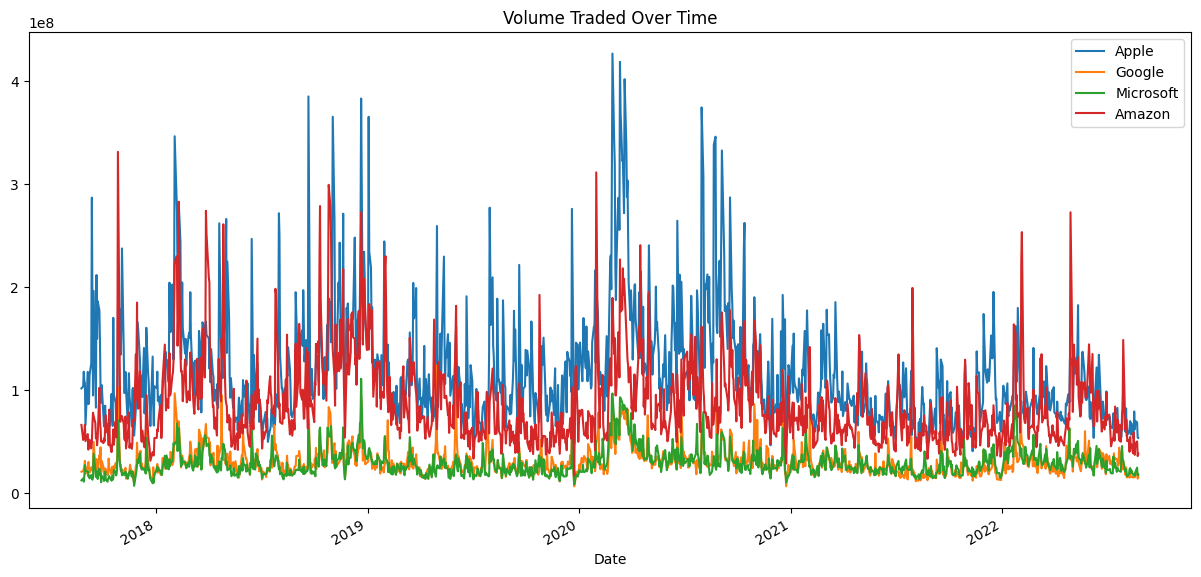

In [16]:
#Visualize the change in a stock’s volume being traded, over time?
fig, ax = plt.subplots(figsize=(15, 7))
for comp in companies:
    stock = grouped.get_group(comp)
    stock['Volume'].plot(legend=True, ax=ax)
ax.legend(companies)
plt.title("Volume Traded Over Time")
plt.show()




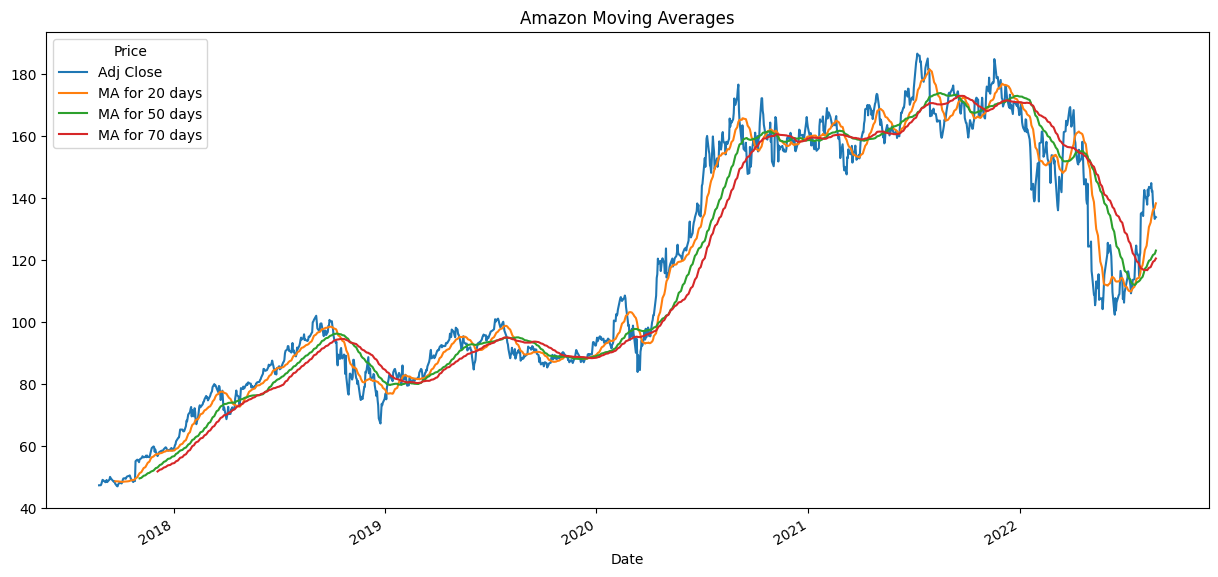

In [17]:
#•What was the moving average of various stocks?
for j in [20, 50, 70]:
    col = f'MA for {j} days'
    AMZN[col] = AMZN['Adj Close'].rolling(window=j, center=False).mean()

AMZN[['Adj Close', 'MA for 20 days', 'MA for 50 days', 'MA for 70 days']].plot(
    figsize=(15, 7), title="Amazon Moving Averages")
plt.show()


In [18]:
AMZN.tail()

Price,Adj Close,Close,High,Low,Open,Volume,Company,MA for 20 days,MA for 50 days,MA for 70 days
Date,,,,,,,,,,
2022-08-18,142.300003,142.300003,142.770004,140.380005,141.320007,37458700,Amazon,135.274501,121.2492,118.958265
2022-08-19,138.229996,138.229996,141.110001,137.910004,140.470001,47792800,Amazon,136.065001,121.5902,119.377850
2022-08-22,133.220001,133.220001,136.320007,132.850006,135.720001,50461500,Amazon,136.669001,121.9316,119.775679
2022-08-23,133.619995,133.619995,134.990005,132.949997,133.410004,36252100,Amazon,137.609501,122.4110,120.156957
2022-08-24,133.800003,133.800003,135.470001,132.100006,132.750000,38627000,Amazon,138.251001,123.0136,120.453315


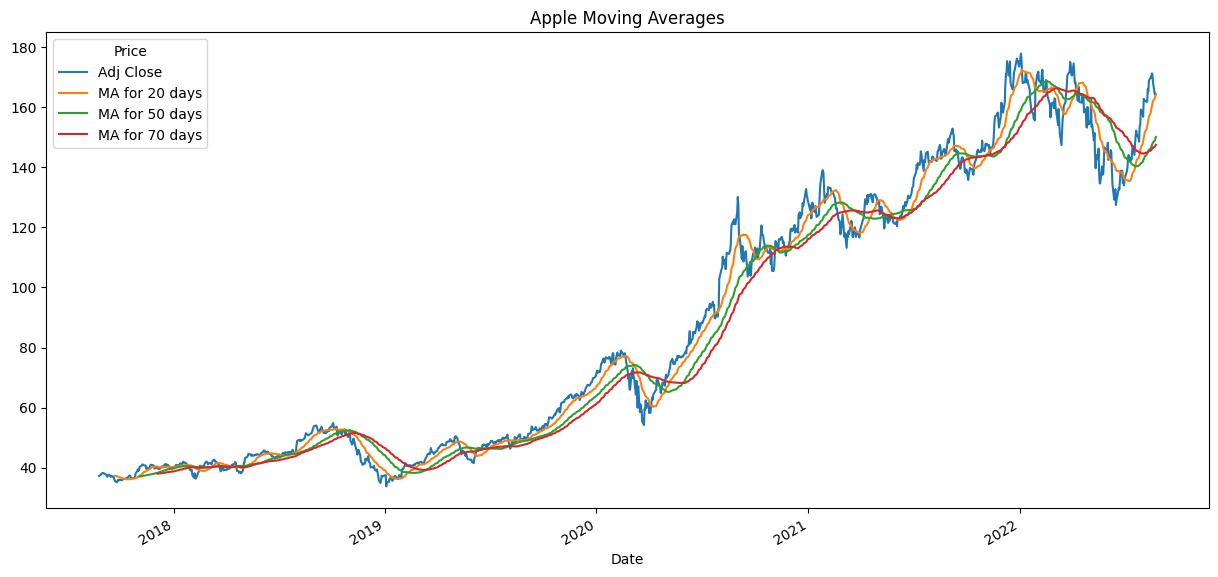

In [19]:
for j in [20, 50, 70]:
    col = f'MA for {j} days'
    AAPL[col] = AAPL['Adj Close'].rolling(window=j, center=False).mean()

AAPL[['Adj Close', 'MA for 20 days', 'MA for 50 days', 'MA for 70 days']].plot(
    figsize=(15, 7), title="Apple Moving Averages")
plt.show()

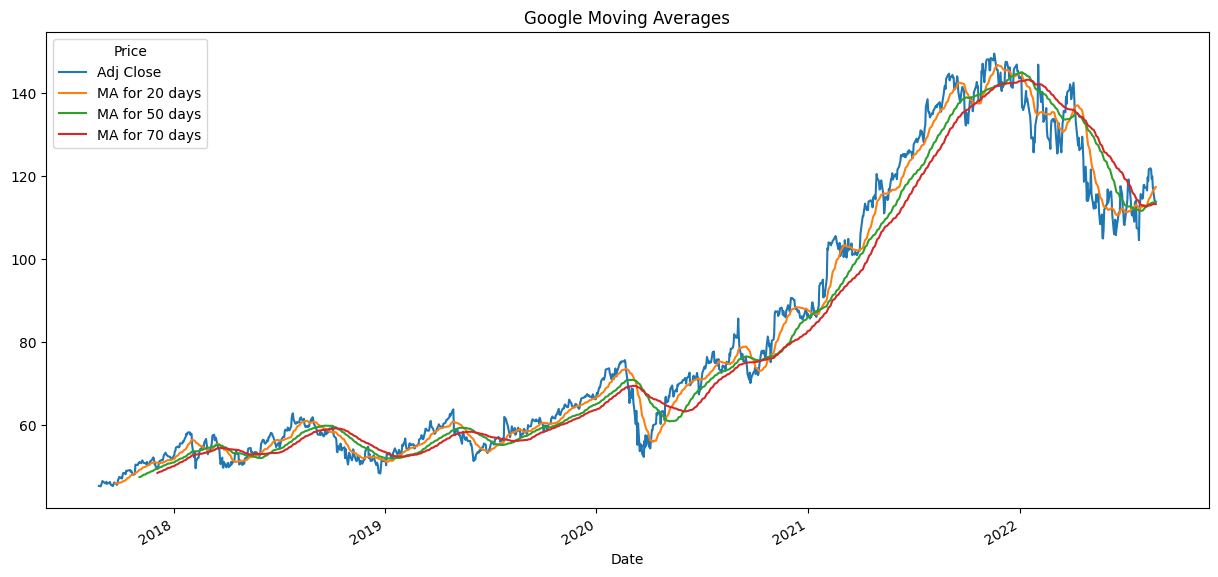

In [20]:
for j in [20, 50, 70]:
    col = f'MA for {j} days'
    GOOG[col] = GOOG['Adj Close'].rolling(window=j, center=False).mean()

GOOG[['Adj Close', 'MA for 20 days', 'MA for 50 days', 'MA for 70 days']].plot(
    figsize=(15, 7), title="Google Moving Averages")
plt.show()

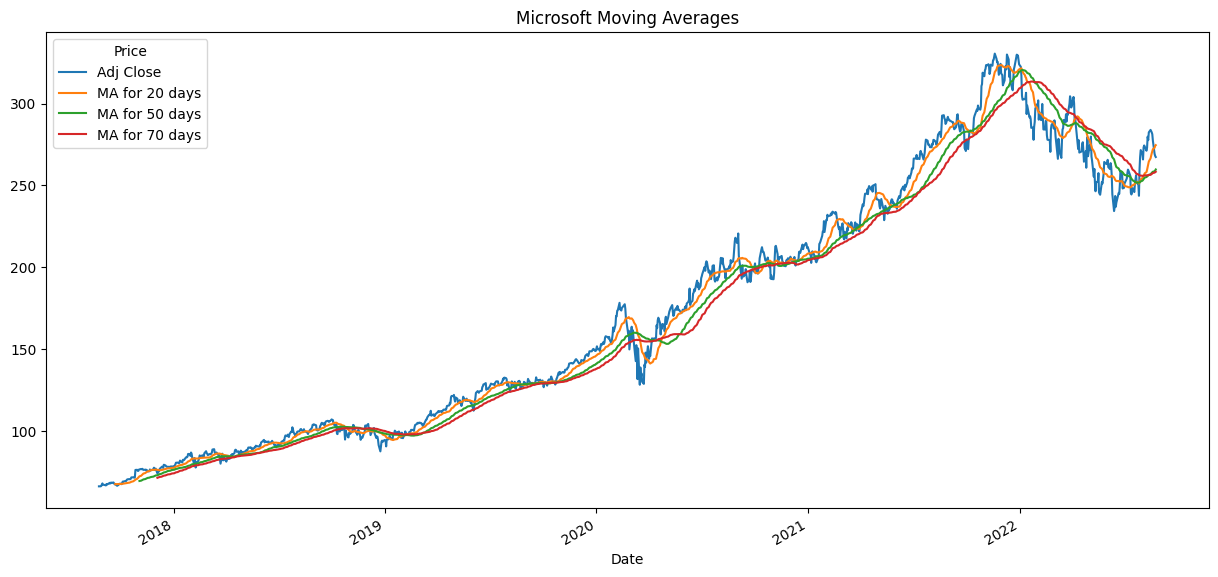

In [21]:
for j in [20, 50, 70]:
    col = f'MA for {j} days'
    MSFT[col] = MSFT['Adj Close'].rolling(window=j, center=False).mean()

MSFT[['Adj Close', 'MA for 20 days', 'MA for 50 days', 'MA for 70 days']].plot(
    figsize=(15, 7), title="Microsoft Moving Averages")
plt.show()

In [22]:
#What was the daily return average of a stock?
stocks['Daily return'] = stocks.groupby('Company')['Adj Close'].pct_change(fill_method=None)


In [23]:
stocks['Daily return'] = stocks['Daily return'].fillna(0)
print(stocks.tail())

Price        Adj Close       Close        High         Low        Open  \
Date                                                                     
2022-08-18  142.300003  142.300003  142.770004  140.380005  141.320007   
2022-08-19  138.229996  138.229996  141.110001  137.910004  140.470001   
2022-08-22  133.220001  133.220001  136.320007  132.850006  135.720001   
2022-08-23  133.619995  133.619995  134.990005  132.949997  133.410004   
2022-08-24  133.800003  133.800003  135.470001  132.100006  132.750000   

Price         Volume Company  Daily return  
Date                                        
2022-08-18  37458700  Amazon      0.001407  
2022-08-19  47792800  Amazon     -0.028602  
2022-08-22  50461500  Amazon     -0.036244  
2022-08-23  36252100  Amazon      0.003003  
2022-08-24  38627000  Amazon      0.001347  


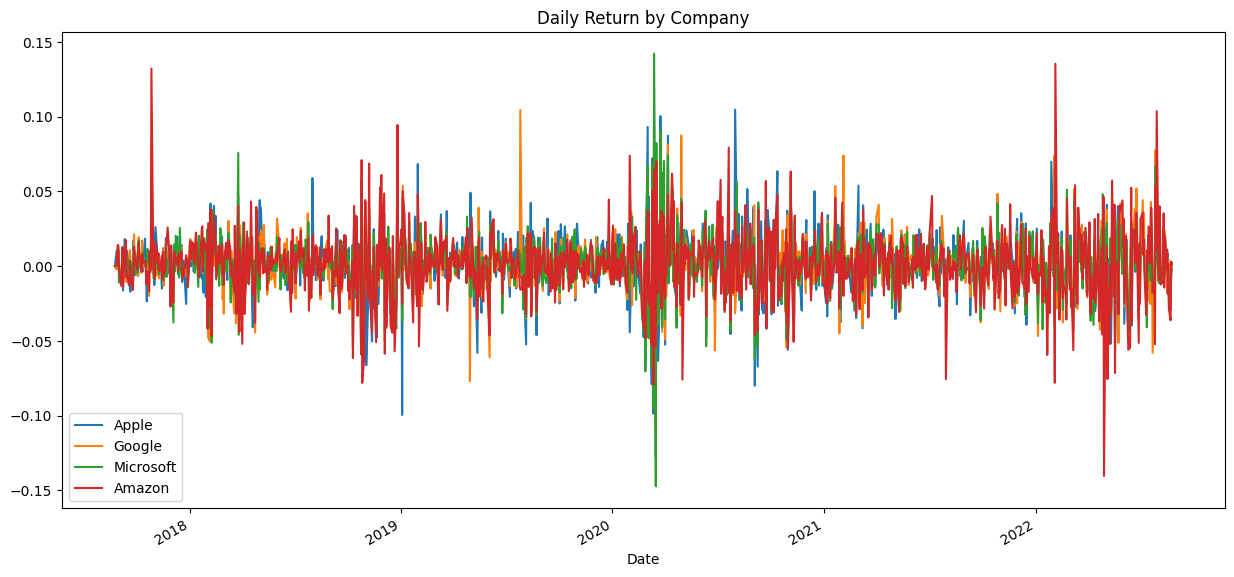

In [24]:
for comp in companies:
    stock = grouped.get_group(comp)  # note: grouped is stale if stocks changed structure; re-group if needed
    pass

# Re-group since 'Daily return' was added after the original groupby
grouped = stocks.groupby('Company')
fig, ax = plt.subplots(figsize=(15, 7))
for comp in companies:
    stock = grouped.get_group(comp)
    stock['Daily return'].plot(legend=True, ax=ax)
ax.legend(companies)
plt.title("Daily Return by Company")
plt.show()


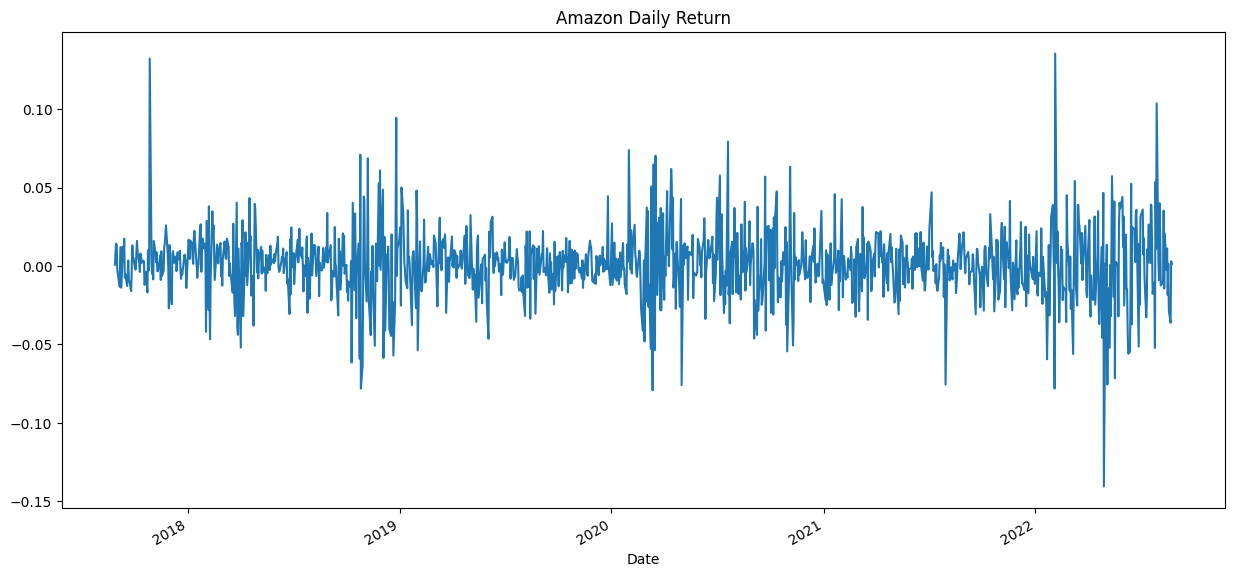

In [25]:
AMZN['Daily return'] = AMZN['Adj Close'].pct_change(fill_method=None)
AMZN['Daily return'].plot(figsize=(15, 7), title="Amazon Daily Return")
plt.show()

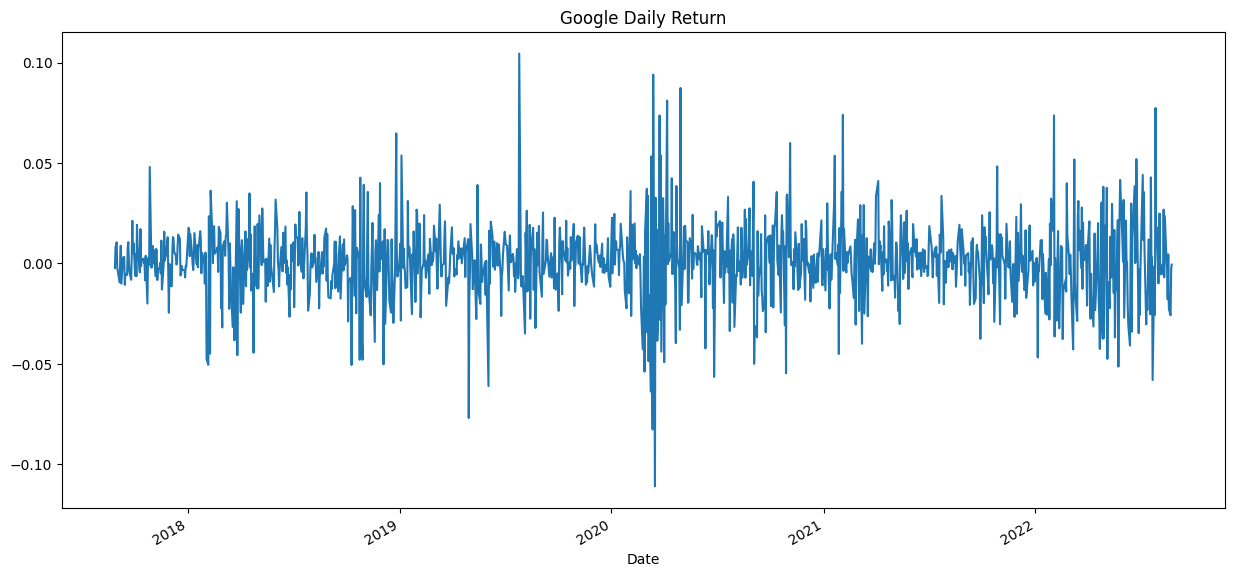

In [26]:
GOOG['Daily return'] = GOOG['Adj Close'].pct_change(fill_method=None)
GOOG['Daily return'].plot(figsize=(15, 7), title="Google Daily Return")
plt.show()

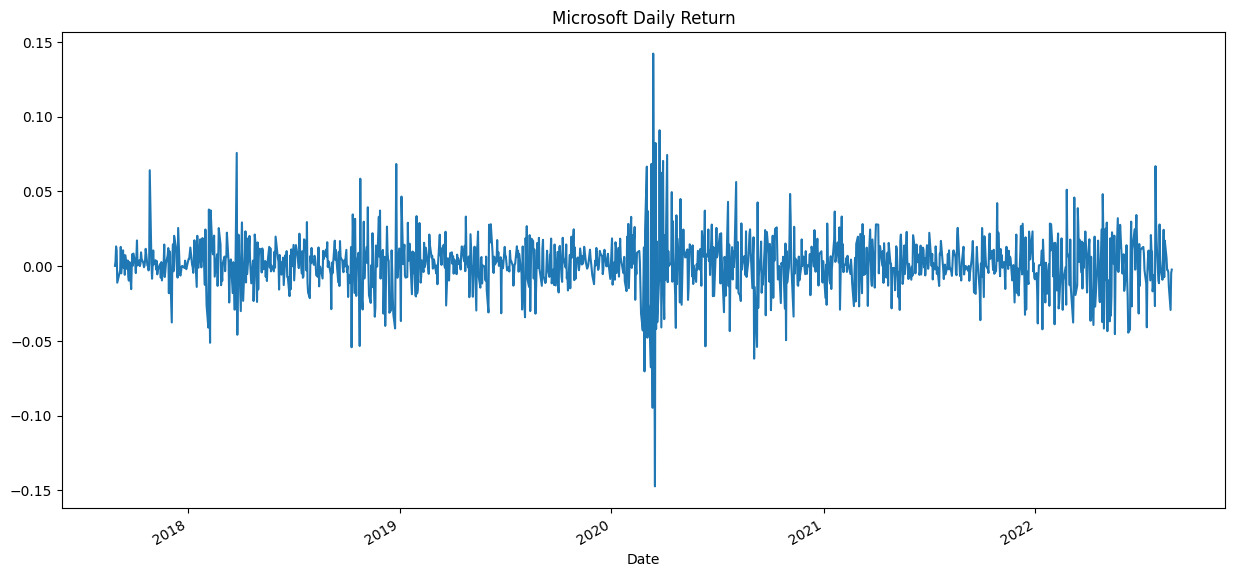

In [27]:
MSFT['Daily return'] = MSFT['Adj Close'].pct_change(fill_method=None)
MSFT['Daily return'].plot(figsize=(15, 7), title="Microsoft Daily Return")
plt.show()

<Axes: xlabel='Date'>

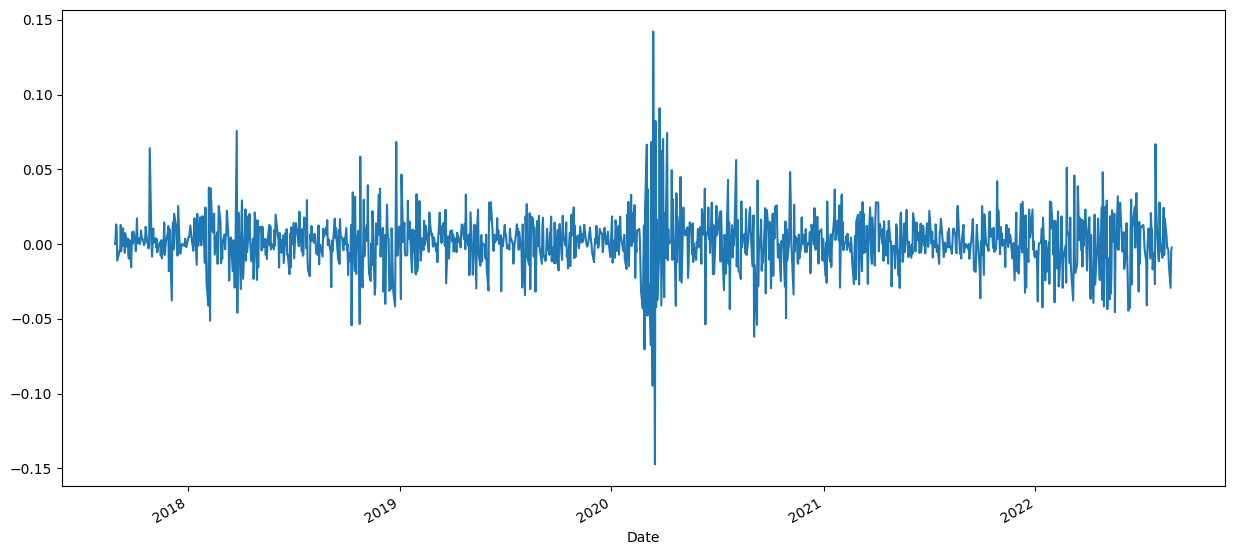

In [28]:
MSFT['Daily return'].plot(figsize=(15,7))

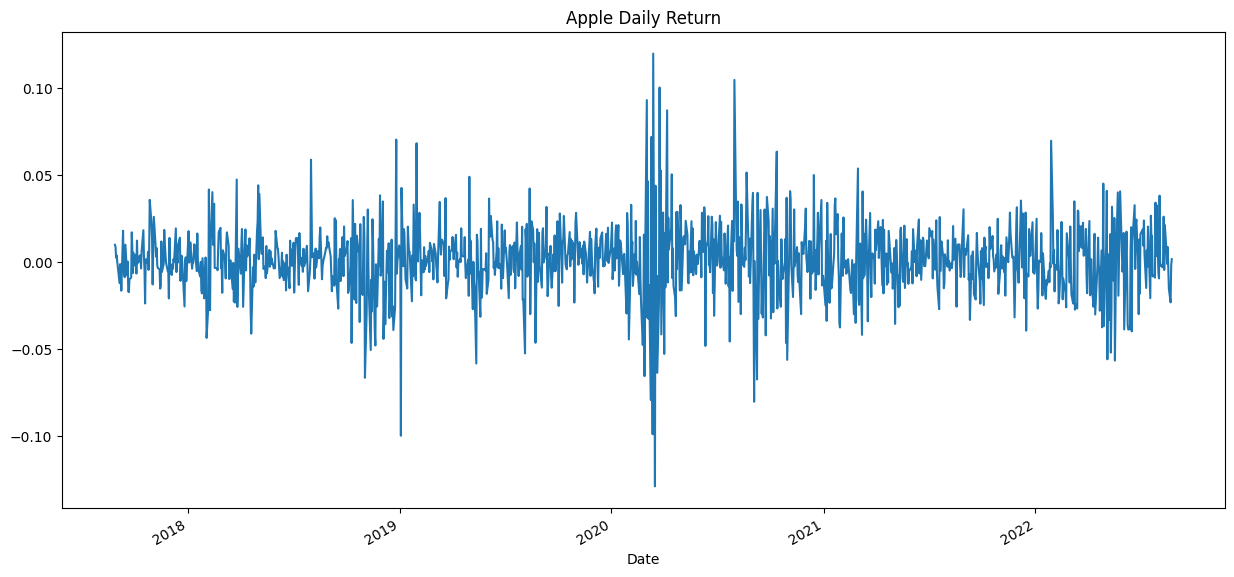

In [29]:
AAPL['Daily return'] = AAPL['Adj Close'].pct_change(fill_method=None)
AAPL['Daily return'].plot(figsize=(15, 7), title="Apple Daily Return")
plt.show()

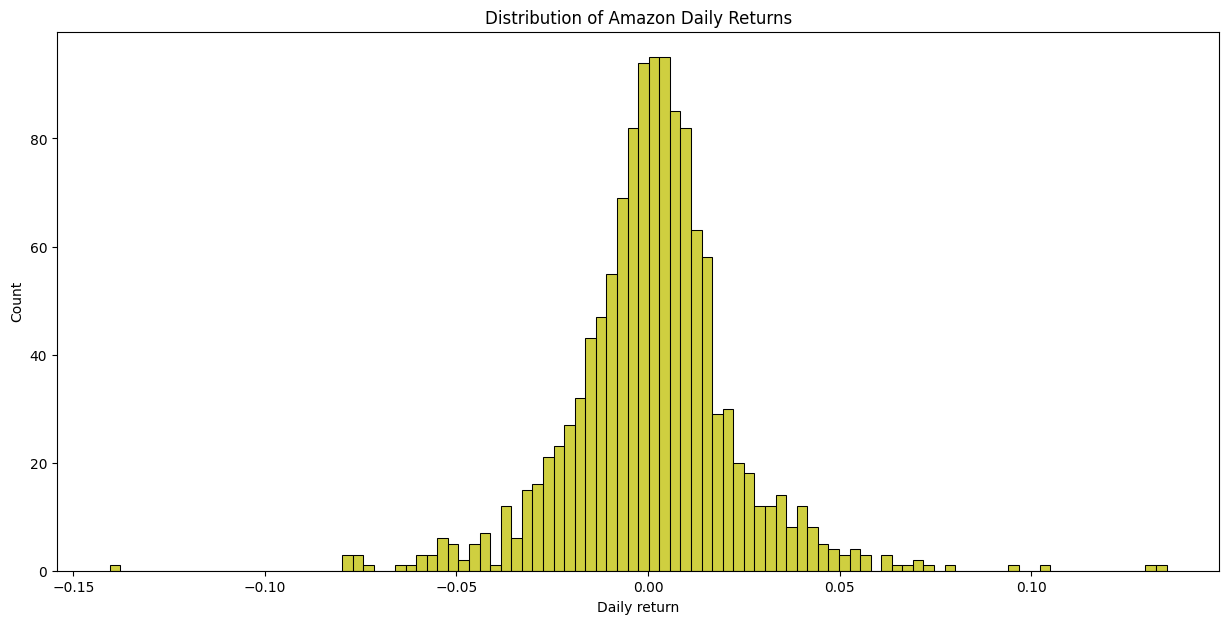

In [30]:
#Adda new column ‘Trend’ whose values are based on the 'Daily Return'
import seaborn as sns
f, ax = plt.subplots(figsize=(15, 7))
sns.histplot(AMZN['Daily return'].dropna(), bins=100, color='y', kde=False, ax=ax)
plt.title("Distribution of Amazon Daily Returns")
plt.show()


In [31]:
def trend(x):
    if x > -0.015 and x <= 0.015:
        return 'Slight or no change'
    elif x > 0.015 and x <= 0.04:
        return 'Slight change'
    elif x > 0.04 and x <= 0.06:
        return 'Positive'
    elif x < -0.04 and x >= -0.06:
        return 'Negative'
    elif x > 0.06 and x <= 0.07:
        return 'Among top gainers'
    elif x > -0.07 and x <= -0.06:
        return 'Among top losers'
    elif x > 0.07:
        return 'Bull run'
    elif x <= -0.07:
        return 'Bear drop'
    return 'Unclassified'

In [32]:
AMZN['Trend'] = AMZN['Daily return'].apply(trend)
print(AMZN.tail())

Price        Adj Close       Close        High         Low        Open  \
Date                                                                     
2022-08-18  142.300003  142.300003  142.770004  140.380005  141.320007   
2022-08-19  138.229996  138.229996  141.110001  137.910004  140.470001   
2022-08-22  133.220001  133.220001  136.320007  132.850006  135.720001   
2022-08-23  133.619995  133.619995  134.990005  132.949997  133.410004   
2022-08-24  133.800003  133.800003  135.470001  132.100006  132.750000   

Price         Volume Company  MA for 20 days  MA for 50 days  MA for 70 days  \
Date                                                                           
2022-08-18  37458700  Amazon      135.274501        121.2492      118.958265   
2022-08-19  47792800  Amazon      136.065001        121.5902      119.377850   
2022-08-22  50461500  Amazon      136.669001        121.9316      119.775679   
2022-08-23  36252100  Amazon      137.609501        122.4110      120.156957   
2

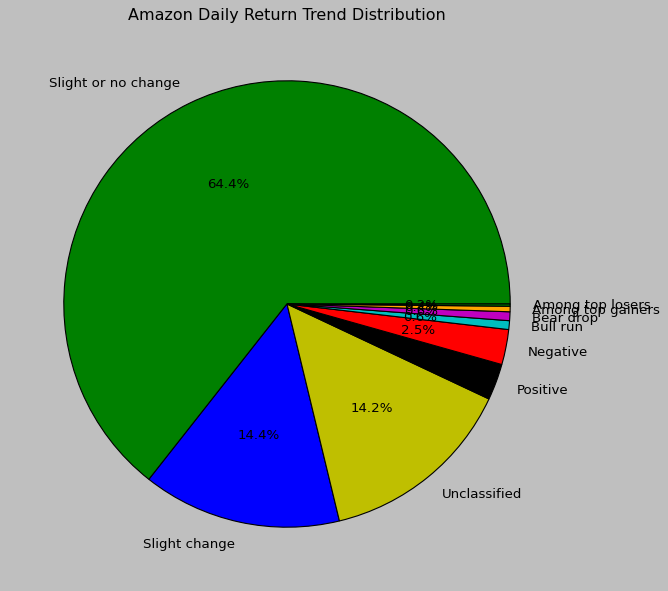

In [33]:
#Visualize trend frequency through a Pie Chart
plt.style.use('classic')
plt.figure(figsize=(9, 9))
pie_colors = ['g', 'b', 'y', 'k', 'r', 'c', 'm', 'orange']
labels = AMZN['Trend'].value_counts().index
sizes = AMZN['Trend'].value_counts().values
plt.pie(sizes, labels=labels, colors=pie_colors[:len(labels)], autopct="%1.1f%%")
plt.title("Amazon Daily Return Trend Distribution")
plt.show()

In [34]:
#•What was the correlation between the daily returns of different stocks?
all_adj = pd.concat(
    [AMZN['Adj Close'], GOOG['Adj Close'], MSFT['Adj Close'], AAPL['Adj Close']],
    axis=1
)
all_adj.columns = ['Amazon', 'Google', 'Microsoft', 'Apple']
print(all_adj)

                Amazon      Google   Microsoft       Apple
Date                                                      
2017-08-25   47.263000   45.394272   66.344246   37.234627
2017-08-28   47.300999   45.291183   66.353394   37.609638
2017-08-29   47.702999   45.661911   66.553818   37.945045
2017-08-30   48.379501   46.072292   67.428444   38.047520
2017-08-31   49.029999   46.556030   68.120850   38.198921
...                ...         ...         ...         ...
2022-08-18  142.300003  119.803734  281.345032  170.960022
2022-08-19  138.229996  117.087669  277.447296  168.378220
2022-08-22  133.220001  114.064331  269.302765  164.500549
2022-08-23  133.619995  113.766960  268.032623  164.166748
2022-08-24  133.800003  113.697563  267.402344  164.461258

[1258 rows x 4 columns]


In [35]:
pct_all = all_adj.pct_change(fill_method=None)
print(pct_all.tail())

              Amazon    Google  Microsoft     Apple
Date                                               
2022-08-18  0.001407  0.004488  -0.003947 -0.002291
2022-08-19 -0.028602 -0.022671  -0.013854 -0.015102
2022-08-22 -0.036244 -0.025821  -0.029355 -0.023030
2022-08-23  0.003003 -0.002607  -0.004716 -0.002029
2022-08-24  0.001347 -0.000610  -0.002352  0.001794


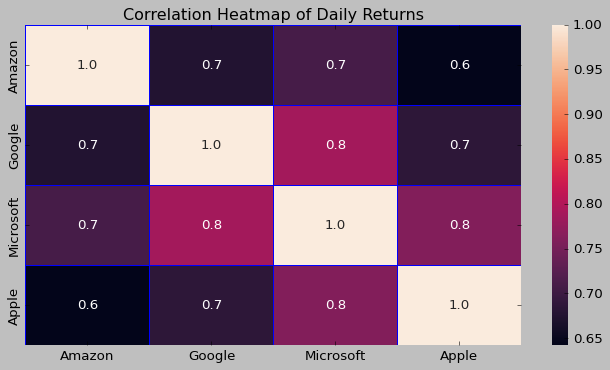

In [36]:
f, ax = plt.subplots(figsize=(10, 5))
plt.style.use('classic')
sns.heatmap(pct_all.corr(), annot=True, linewidth=0.6, linecolor='b', fmt='.1f', ax=ax)
plt.title("Correlation Heatmap of Daily Returns")
plt.show()